## 1 - The image files in the directory `../Data`

The directory `Data` in the root directory contains the image files:

In [6]:
os.listdir('..')

['Data',
 'uv.lock',
 'pyproject.toml',
 '.gitignore',
 '.python-version',
 'Notebooks',
 'README.md',
 '.venv',
 '.git']

Lest's define `data_dir` : the relative path to the data directory:

In [7]:
data_dir = Path('../Data')

Now we build the ordered list of the subdirs in `data_dir`:

In [8]:
data_subdirs = sorted(list(data_dir.iterdir()))
data_subdirs

[PosixPath('../Data/0-Hypoeutectoid_steel'),
 PosixPath('../Data/1-Hypoeutectic_white_cast_iron'),
 PosixPath('../Data/2-Hypereutectoid_steel')]

### Check: display some images

Let's display the first JPG files in the three image directories: we read the JPG files with the function `imread` of the `openCV` module, wich returns a `ndarray` of the image pixels:

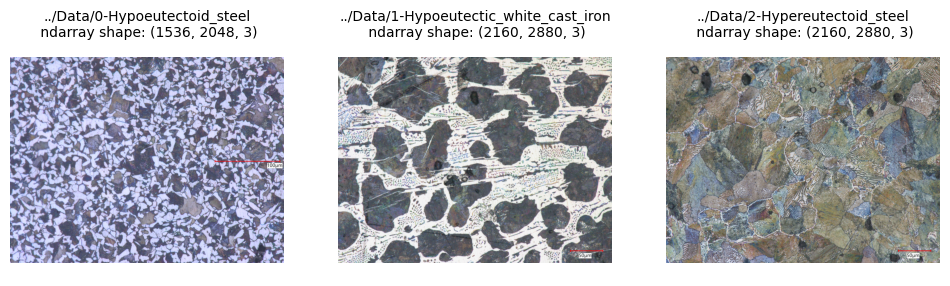

In [9]:
fig, axes = plt.subplots(1, 3)
fig.set_size_inches((12,3))

for subdir, axis in zip(data_subdirs, axes):
    files = sorted(subdir.glob('**/*.jpg'))   # '**/*.jpg' means: all the *.jpg files in 'subdir'
    imBGR = cv2.imread(files[0])              # load the image file
    imRGB = cv2.cvtColor(imBGR, cv2.COLOR_BGR2RGB)
    # display images:
    axis.imshow(imRGB)
    axis.set_title(f'{subdir}\n ndarray shape: {imRGB.shape}', fontsize=10) 
    axis.axis('off')
    axis.axis('equal')

### Check: size of the images

In [10]:
shapes = []
for subdir in data_subdirs:
    files = sorted(subdir.glob('**/*.jpg'))              # '**/*.jpg' means: all the *.jpg files in 'subdir'
    print(f'collecting image size in subdir "{subdir.name}"')
    for file in files:
        img = cv2.imread(file)
        h, w, _ = img.shape
        shapes.append((w, h))
print(f'Found image sizes: {set(shapes)}')

collecting image size in subdir "0-Hypoeutectoid_steel"
collecting image size in subdir "1-Hypoeutectic_white_cast_iron"
collecting image size in subdir "2-Hypereutectoid_steel"
Found image sizes: {(2048, 1536), (2880, 2160)}


All the images have not the same size => we will have to resize the images to a common size.

## 2 - Preprocessing of the images

__Size__:<br>
- all the images must have the same size
- the size of the images should not be too large if we want acceptable computation times...

$\leadsto$ the micrographs available are high resolution images ( 2048$\times$1536 and 2880$\times$2160 ): we will lower the image size to __(520, 400)__ with the fucntion `resize` of the `openCV` module.

__RGB__  or __gray tones__:<br>
If the color information of the images is not relevant for their classification, we can gain calculation time and minimize the memory footprint by converting the images into gray tones.

$\leadsto$ As the color is not the main classification information, lets's convert the RGB images to gray-tone images with the `cvtColor` function of OpenCV.

### Example:

Let's resize and convert in gray the first images of the three image sub-directories:

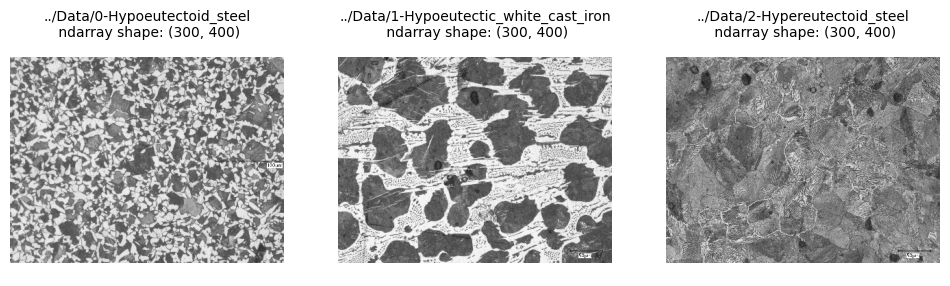

In [11]:
fig, axes = plt.subplots(1, 3)
fig.set_size_inches((12,3))

for subdir, axis in zip(data_subdirs, axes):
    files = sorted(subdir.glob('**/*.jpg'))      # '**/*.jpg' means: all the *.jpg files in 'subdir'
    img = cv2.imread(files[0])                   # load the first image
    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # convert color image into grayscale image
    img = cv2.resize(img, dsize=(400, 300))      # new size given as: (width, height)
    axis.imshow(img, cmap='gray')
    axis.set_title(f'{subdir}\n ndarray shape: {img.shape}', fontsize=10) 
    axis.axis('off')
    axis.axis('equal')

### Building the data set

Now:<br>
- we load into a single ndarray all the images resized and converted in gray tone<br>
- we build the `labels` ndarray.

In [22]:
data_dir     = Path('../Data')  # the data directory
data_subdirs = sorted(list(data_dir.iterdir()))

# Initiallize empty lists:
images, labels = [], []
label_rank, label_text = [], []

for rank, subdir in enumerate(data_subdirs):
    label_rank.append(rank)
    label_text.append(subdir.name)
    print(f'Building dataset for material: label:{rank}, subdir: {subdir.name}')
    files = list(subdir.glob("*.jpg"))             # '**/*.jpg' means: all the *.jpg files in 'subdir'
    files.sort()
    for f in files:
        print(f'\r\treading file {f.name}', end='')
        img = cv2.imread(f)                        # load the first image
        img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) # convert color image into grayscale image
        img = cv2.resize(img, dsize=(600, 500))    # new size given as: (width, height)
        
        images.append(img)
        labels.append(rank)
    print(f'\r\tdone{40*" "}')
    
# convert lists as ndarrays:    
images = np.array(images)
labels = np.array(labels)

Building dataset for material: label:0, subdir: 0-Hypoeutectoid_steel
	done                                        
Building dataset for material: label:1, subdir: 1-Hypoeutectic_white_cast_iron
	done                                        
Building dataset for material: label:2, subdir: 2-Hypereutectoid_steel
	done                                        


In [23]:
label_text, list(label_rank)

(['0-Hypoeutectoid_steel',
  '1-Hypoeutectic_white_cast_iron',
  '2-Hypereutectoid_steel'],
 [0, 1, 2])

How many image in total:

In [24]:
len(images)

320

#### Check the size of the first and last images:

In [25]:
images[0].shape, images[-1].shape

((500, 600), (500, 600))

Summary:

In [26]:
print(f'{images.shape=}, {images.dtype=}')
print(f'{labels.shape=}, {labels.dtype=}')
print(f"total size of the {len(images)} images ndarray in memory: {images.size/1024/1024:.1f} MiB")

images.shape=(320, 500, 600), images.dtype=dtype('uint8')
labels.shape=(320,), labels.dtype=dtype('int64')
total size of the 320 images ndarray in memory: 91.6 MiB


## 3 - Prepare the _train_, _valid_ and _test_ data sets

### Split the full datset into train, valid & test datasets

Thanks to the `train_test_split` function of the `sklearn` module we can split the `images` and `labels` ndarrays into sub-datasets.<br>
Images and labels are randomly selected but respecting the proportion of each of the 3 classes in the original dataset (this is the interest of the `stratify` argument of the `train_test_split` function).

Following the state of the art in Deep Learning, we will split the full dataset into 3 sub-datasets:
- a `train` dataset (for the training)
- a `valid` dataset (for the validation during the model training)
- a 'test' dataset to evaluate the model score after training.

$\leadsto$ See the fucntion `split_stratified_into_train_val_test` in the module `toolos` from the `utils` directory.<br>



In [27]:
train_dataset, valid_dataset, test_dataset = split_stratified_into_train_val_test((images, labels), 
                                                                                  frac_train=0.8, 
                                                                                  frac_val=0.1,
                                                                                  frac_test=0.1, 
                                                                                  shuffle=False,
                                                                                  seed=SEED)
# Extract image and label arrays from the datasets:
train_img, train_lab = train_dataset
valid_img, valid_lab = valid_dataset
test_img, test_lab = test_dataset

### Data set parameters:

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are recovered from the data set:
- with the shape attribute of the `im_train` and `im_test` arrays
- with the size attribute of the first training image for example


In [28]:
NB_TRAIN_IMG = train_img.shape[0] # number of training images
NB_VALID_IMG = valid_img.shape[0] # number of validation images 
NB_TEST_IMG  = test_img.shape[0]  # number of test images

NB_PIXEL     = train_img[0].size  # number of elements (pixels) of the firts training image: 

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")

# number of classes:
NB_CLASS = len(set(train_lab))
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

256 training images, 32 validation images and 32 test images
500x600=300000 pixels in each image
3 classes found in the `train_lab` ndarray


#### Check: display the shapes of the dataset arrays

In [29]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (256, 500, 600)
valid:  (32, 500, 600)
test :  (32, 500, 600)


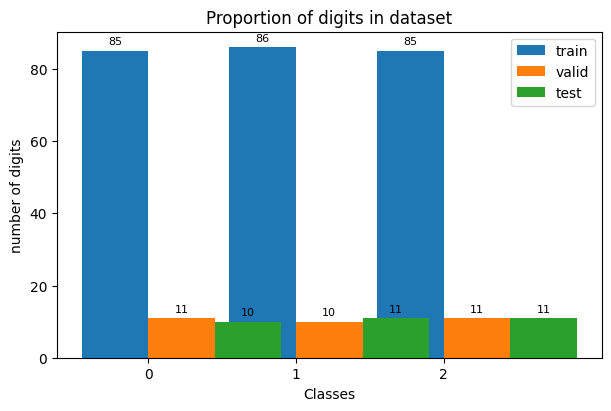

In [30]:
prop = {}
prop['train'] = [ (train_lab == i).sum() for i in range(NB_CLASS)]
prop['valid'] = [ (valid_lab == i).sum() for i in range(NB_CLASS)]
prop['test']  = [ (test_lab  == i).sum() for i in range(NB_CLASS)]
plot_proportion_bar(prop, range(NB_CLASS))

#### Check: display a train image randomy selected

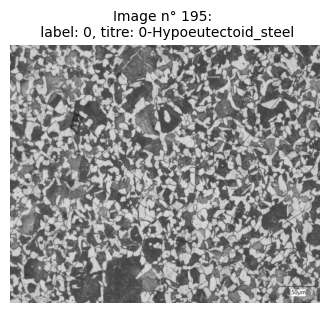

In [31]:
img_rank = np.random.randint(0, len(train_img))

plt.figure(figsize=(4,4))
plt.imshow(train_img[img_rank], cmap='gray')
plt.title(f'Image n° {img_rank}: \n label: {train_lab[img_rank]}, titre: {label_text[train_lab[img_rank]]}',
          fontsize=10)
plt.axis('off');

### Transform image matrices into normalized vectors

We define the arrays `x_train`, `x_valid` and `x_test` containing the data of the arrays `train_img`, `valid_img` and `test_imd` _flattened_ as normalized vectors (values between 0 and 1):

In [32]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

train: (256, 300000), min: 0.0, max: 1.0
valid: (32, 300000), min: 0.0, max: 1.0
test : (32, 300000), min: 0.0, max: 1.0


### One-hot formatting of labels

The labels data must be given as an array of vectors _one-hot_ coding the integer value of the labels:

In [33]:
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

#### Check: display the first 10 values of `train_lab` and `y_train` :

In [34]:
print(train_lab[:10])
print(y_train[:10])

[0 1 0 0 1 0 0 1 1 2]
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
